Import the Required Libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from qiskit.visualization import plot_coupling_map, plot_gate_map
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from IPython.display import display

Create a Simple Quantum Circuit

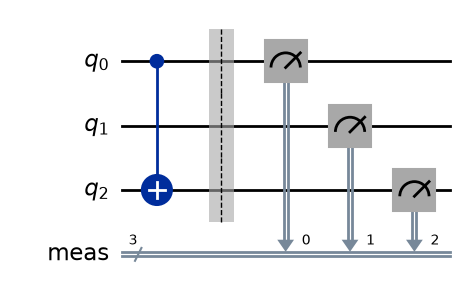

In [2]:
qc = QuantumCircuit(3)
qc.cx(0, 2)
qc.measure_all()

display(qc.draw('mpl'))

Define the Hardware Coupling Map

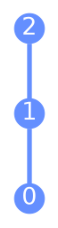

In [3]:
coupling_list = [[0, 1], [1, 2]]
coupling_map = CouplingMap(coupling_list)

fig_map = plot_coupling_map(3, qubit_coordinates=[[0, 0], [1, 0], [2, 0]], coupling_map=coupling_list)
display(fig_map)

Transpile the Circuit

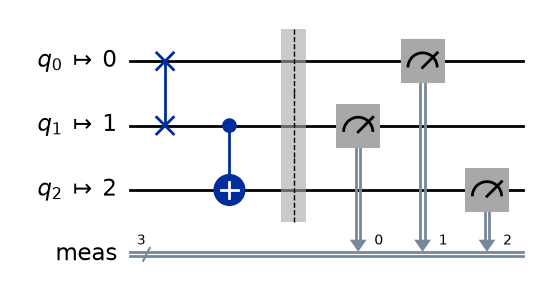

In [4]:
transpiled_qc = transpile(qc, coupling_map=coupling_map, initial_layout=[0, 1, 2])

display(transpiled_qc.draw('mpl'))

Visualize the Difference

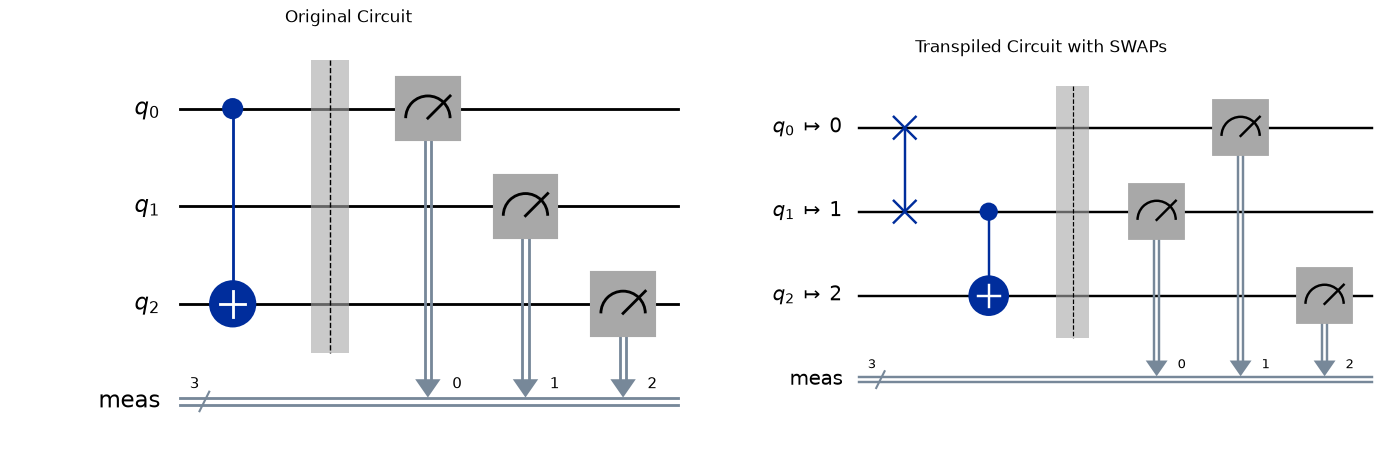

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
qc.draw('mpl', ax=ax1)
ax1.set_title("Original Circuit")
transpiled_qc.draw('mpl', ax=ax2)
ax2.set_title("Transpiled Circuit with SWAPs")
plt.tight_layout()
plt.show()

Run the Transpiled Circuit on the AerSimulator

In [6]:
simulator = AerSimulator()
job = simulator.run(transpiled_qc, shots=1024)
counts = job.result().get_counts()
print("Measurement results:", counts)

Measurement results: {'000': 1024}


Complete Code

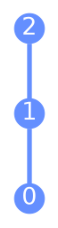

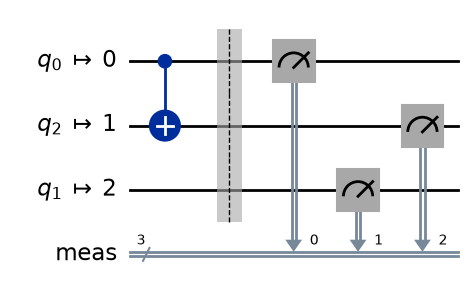

Measurement results: {'000': 1024}


In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from qiskit.visualization import plot_coupling_map
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(3)
qc.cx(0, 2)
qc.measure_all()

coupling_list = [[0, 1], [1, 2]]
coupling_map = CouplingMap(coupling_list)

display(plot_coupling_map(3, qubit_coordinates=[[0, 0], [1, 0], [2, 0]], coupling_map=coupling_list))

transpiled_qc = transpile(qc, coupling_map=coupling_map, optimization_level=1)
display(transpiled_qc.draw('mpl'))

simulator = AerSimulator()
job = simulator.run(transpiled_qc, shots=1024)
counts = job.result().get_counts()
print("Measurement results:", counts)